In [1]:
import numpy as np
import pandas as pd
df = pd.read_csv("penguins_size.csv")
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


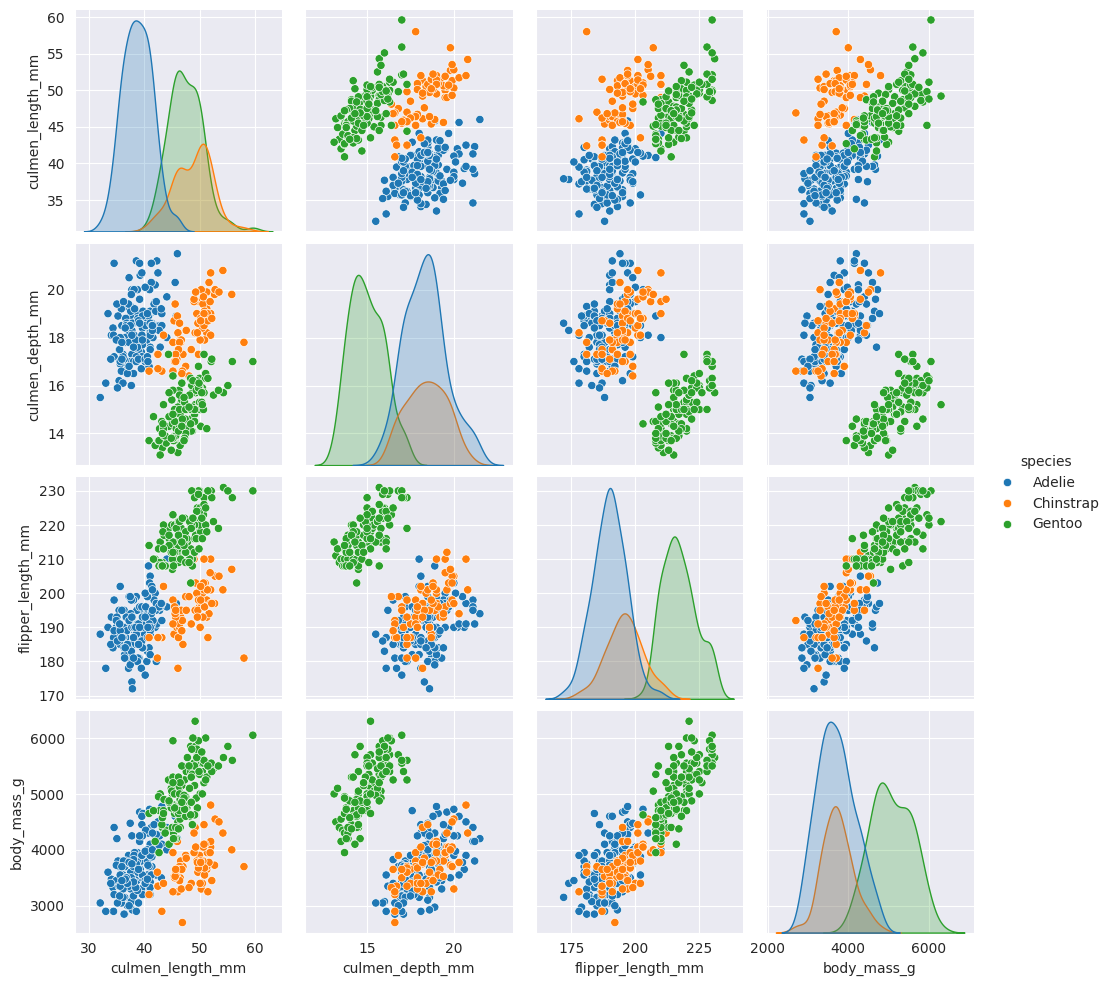

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# df.info()
sns.pairplot(df, hue="species")
plt.show()

In [3]:
df.shape

(344, 7)

In [4]:
df.dtypes

species               object
island                object
culmen_length_mm     float64
culmen_depth_mm      float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [5]:
df["sex"].unique()

array(['MALE', 'FEMALE', nan, '.'], dtype=object)

In [6]:
df["island"].unique()

array(['Torgersen', 'Biscoe', 'Dream'], dtype=object)

In [7]:
df["culmen_length_mm"].unique()

array([39.1, 39.5, 40.3,  nan, 36.7, 39.3, 38.9, 39.2, 34.1, 42. , 37.8,
       41.1, 38.6, 34.6, 36.6, 38.7, 42.5, 34.4, 46. , 37.7, 35.9, 38.2,
       38.8, 35.3, 40.6, 40.5, 37.9, 37.2, 40.9, 36.4, 42.2, 37.6, 39.8,
       36.5, 40.8, 36. , 44.1, 37. , 39.6, 37.5, 42.3, 40.1, 35. , 34.5,
       41.4, 39. , 35.7, 41.3, 41.6, 35.5, 41.8, 33.5, 39.7, 45.8, 42.8,
       36.2, 42.1, 42.9, 35.1, 37.3, 36.3, 36.9, 38.3, 34. , 38.1, 33.1,
       43.2, 41. , 45.6, 42.7, 40.2, 35.2, 41.5, 38.5, 43.1, 36.8, 35.6,
       32.1, 40.7, 46.5, 50. , 51.3, 45.4, 52.7, 45.2, 46.1, 46.6, 51.7,
       47. , 52. , 45.9, 50.5, 50.3, 58. , 46.4, 49.2, 42.4, 48.5, 50.6,
       46.7, 49.5, 52.8, 54.2, 51. , 49.7, 47.5, 47.6, 46.9, 53.5, 49. ,
       46.2, 50.9, 45.5, 50.8, 50.1, 51.5, 49.8, 48.1, 51.4, 45.7, 50.7,
       52.2, 49.3, 50.2, 51.9, 46.8, 55.8, 43.5, 49.6, 48.7, 43.3, 48.4,
       45.1, 46.3, 44.5, 47.8, 48.2, 47.3, 59.6, 49.1, 42.6, 44.4, 44. ,
       45.3, 43.6, 44.9, 45. , 43.8, 50.4, 54.3, 47

In [8]:
df.isnull().sum()

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

In [9]:
#finding the percentage of null values
df.isnull().sum()/len(df)*100

species              0.000000
island               0.000000
culmen_length_mm     0.581395
culmen_depth_mm      0.581395
flipper_length_mm    0.581395
body_mass_g          0.581395
sex                  2.906977
dtype: float64

In [10]:
#finding duplicate fields
df.duplicated().sum()

np.int64(0)

In [11]:
#find garbage values
for i in df.select_dtypes(include='object'):
    print(df[i].value_counts())
    print('*'*50)

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64
**************************************************
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64
**************************************************
sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64
**************************************************


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
culmen_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
culmen_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


In [13]:
df.describe(include='object').T

,count,unique,top,freq
species,344,3,Adelie,152
island,344,3,Biscoe,168
sex,334,3,MALE,168


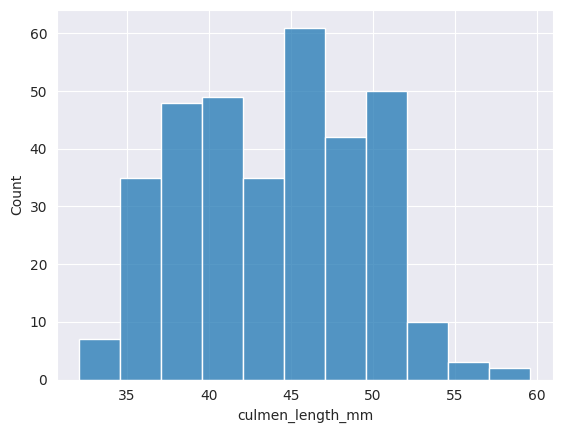

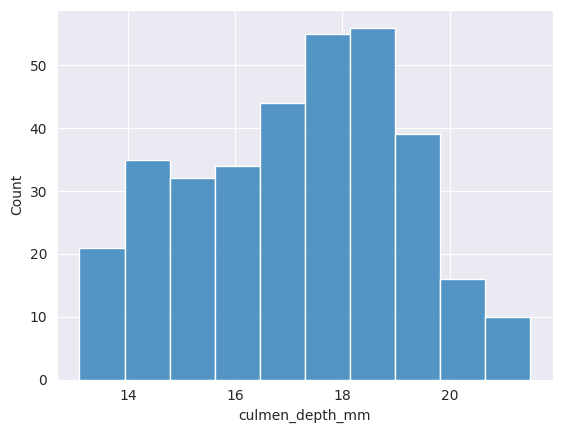

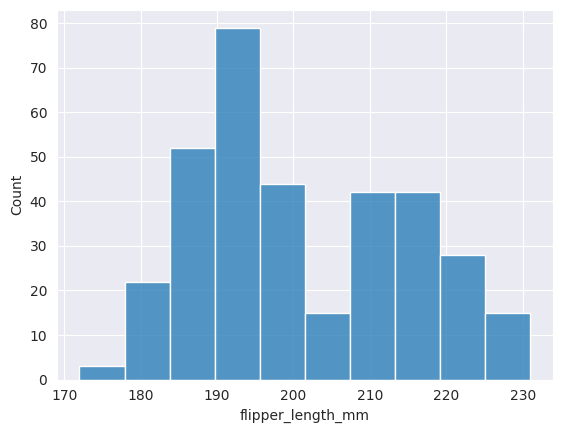

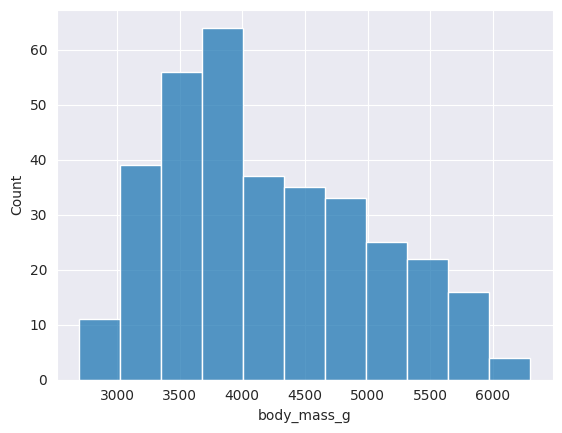

In [14]:
for i in df.select_dtypes(include='number').columns:
    sns.histplot(data=df,x=i)
    plt.show()

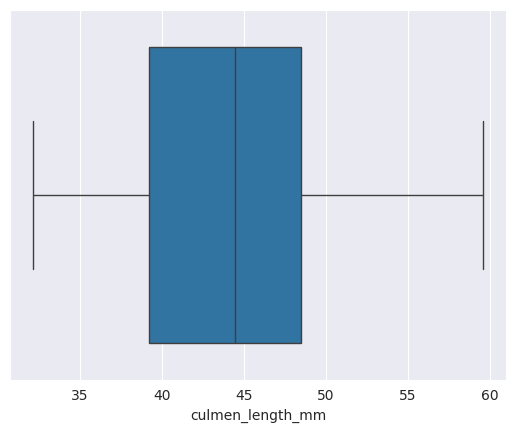

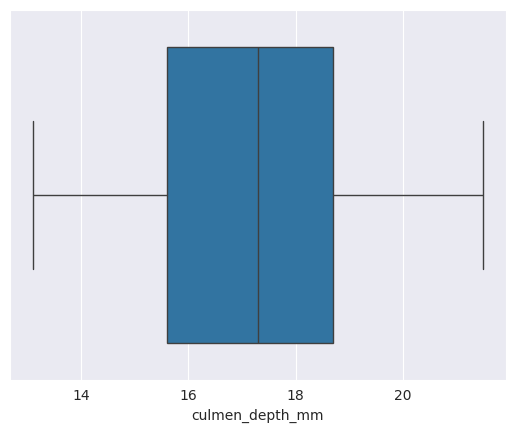

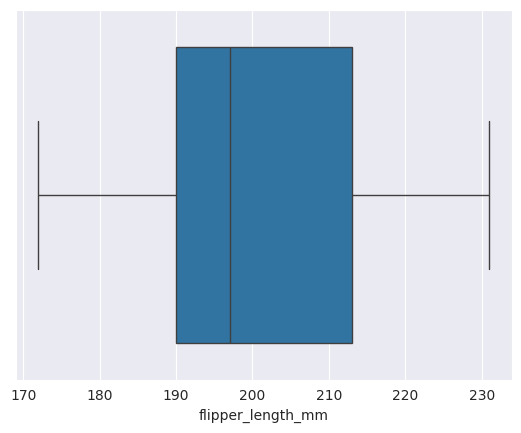

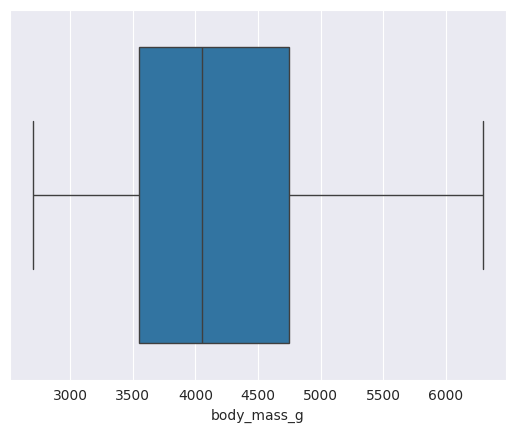

In [15]:
#boxplot to understand if there is outliers
for i in df.select_dtypes(include='number').columns:
    sns.boxplot(data=df,x=i)
    plt.show()

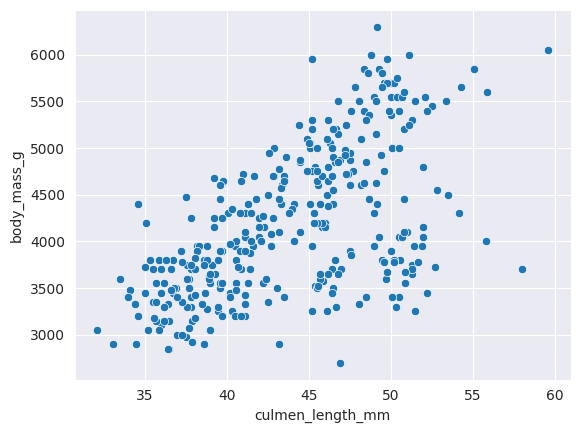

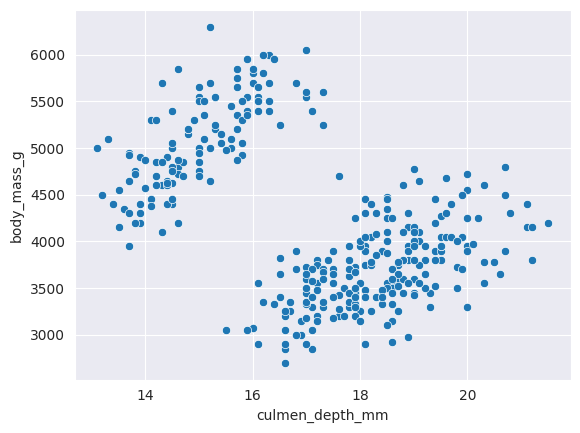

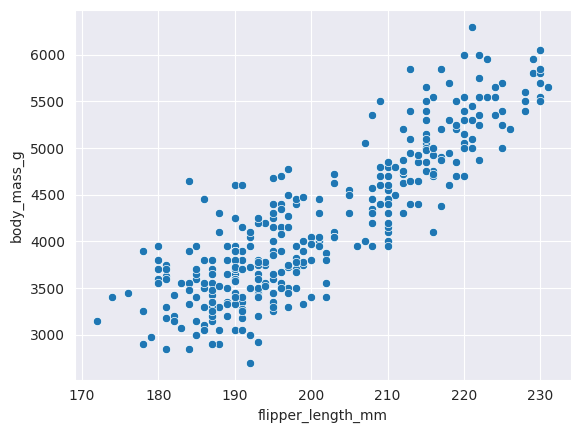

In [16]:
#generating scatter plot to see the relatioship between all column and body_mass_g
for i in ['culmen_length_mm','culmen_depth_mm','flipper_length_mm']:
    sns.scatterplot(data=df,x=i,y='body_mass_g')
    plt.show()

In [17]:
#showing correlation bw the data
corr = df.select_dtypes(include='number').corr()

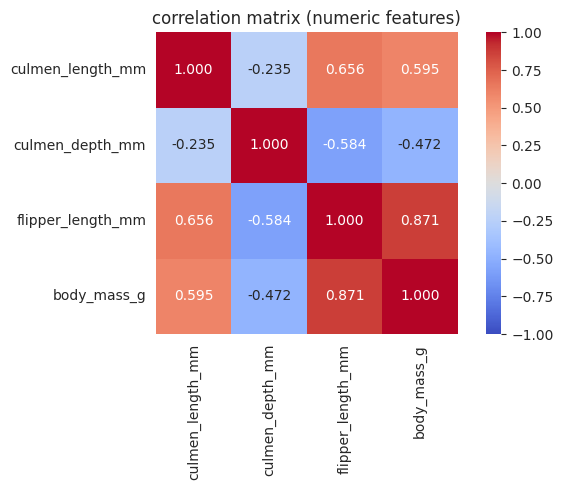

In [18]:
plt.figure(figsize=(7,5))
sns.heatmap(corr,annot=True,cmap='coolwarm',vmin=-1,vmax=1,fmt=".3f",square=True)
plt.title("correlation matrix (numeric features)")
plt.tight_layout()
plt.show()

In [19]:
#treating missing values

In [20]:
print(df.isnull().sum())

species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64


In [21]:
'''
two main strategies
1. removing missing values : df.dropna(inplace=True)
2. imputing missing values :
mean,median,mode
'''

'\ntwo main strategies\n1. removing missing values : df.dropna(inplace=True)\n2. imputing missing values :\nmean,median,mode\n'

In [22]:
'''
mean imputation
- reaplce missing values with the mean of the column
- works well if data id normally distributed

median imputation
- replace missing values with the median of the column
- better then mean if data has outliers or skewed distrinbution

mode imputation
- replce missing values with the most frequent value
- used for categorical features like sex or species

knn imputation
- replace missing values with the mean of the nearest neighbours
- works well for outliers
'''

'\nmean imputation\n- reaplce missing values with the mean of the column\n- works well if data id normally distributed\n\nmedian imputation\n- replace missing values with the median of the column\n- better then mean if data has outliers or skewed distrinbution\n\nmode imputation\n- replce missing values with the most frequent value\n- used for categorical features like sex or species\n\nknn imputation\n- replace missing values with the mean of the nearest neighbours\n- works well for outliers\n'

In [23]:
'''
we are gonna go with mean imputation for this dataset
and mode imputation for species
'''

#identify numerical and categorical columns
num_cols = df.select_dtypes(include=['float64','int64']).columns
cat_cols = df.select_dtypes(include=['object','category']).columns

In [24]:
#fill missing values with mean
for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [25]:
#categorical fill with mode
for col in cat_cols:
    mode_values = df[col].mode()
    if not mode_values.empty:
        df[col] = df[col].fillna(mode_values[0])
    else:
        #if the column is completely NaN,fill with a placeholder or keep as it is
        df[col] = df[col].fillna('unknown')

In [26]:
print(df.isnull().sum())

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64


In [28]:
#replace '.' with NaN
import numpy as np
df["sex"] = df["sex"].replace(".",np.nan)

In [29]:
# standardize a case (optional but recommended)
df["sex"] = df["sex"].str.upper()

In [30]:
df["sex"].unique()

array(['MALE', 'FEMALE', nan], dtype=object)

In [31]:
#imputing with mode
df["sex"] = df["sex"].fillna(df["sex"].mode()[0])

In [32]:
df["sex"].unique()

array(['MALE', 'FEMALE'], dtype=object)

In [33]:
import pandas as pd

cat_cols = df.select_dtypes(include=['object']).columns

# One-hot encode these categorical columns
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)


In [34]:
print(df_encoded.head())
print(df_encoded.shape)

   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g  \
0          39.10000         18.70000         181.000000  3750.000000   
1          39.50000         17.40000         186.000000  3800.000000   
2          40.30000         18.00000         195.000000  3250.000000   
3          43.92193         17.15117         200.915205  4201.754386   
4          36.70000         19.30000         193.000000  3450.000000   

   species_Adelie  species_Chinstrap  species_Gentoo  island_Biscoe  \
0            True              False           False          False   
1            True              False           False          False   
2            True              False           False          False   
3            True              False           False          False   
4            True              False           False          False   

   island_Dream  island_Torgersen  sex_FEMALE  sex_MALE  
0         False              True       False      True  
1         False         

In [35]:
'''
the next steps after encoding the data is:
1. split the data (80/20 is the best) -> train/test
2. scale features
3. train a model
4. predict
5. evaluate
6. tune/improve model
7. save and export
'''

'\nthe next steps after encoding the data is:\n1. split the data (80/20 is the best) -> train/test\n2. scale features\n3. train a model\n4. predict\n5. evaluate\n6. tune/improve model\n7. save and export\n'

In [36]:
#splitting your data into train/test
from sklearn.model_selection import train_test_split
x=df.drop('species',axis=1)
y=df['species']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [37]:
#binary classification demo

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

'''
load dataset
load_diabetes target is continous (0-300)
to convert into binary, we classify
1 = above median (high,risk) 0 = below median (low risk)
'''
raw = load_diabetes()
df = pd.DataFrame(raw.data, columns=raw.feature_names)

#create binary target
df['target'] = (raw.target > raw.target.mean()).astype(int)

#split
x = df.drop('target',axis=1)
y = df['target']

x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

#model
model = LogisticRegression(max_iter=5000)
model.fit(x_train,y_train)

#predictions
preds = model.predict(x_test)

#evaluation
print("Accuracy" , accuracy_score(y_test,preds))
print("Classification Report")
print(classification_report(y_test,preds))

Accuracy 0.7640449438202247
Classification Report
              precision    recall  f1-score   support

           0       0.71      0.98      0.82        50
           1       0.95      0.49      0.64        39

    accuracy                           0.76        89
   macro avg       0.83      0.73      0.73        89
weighted avg       0.82      0.76      0.74        89



In [ ]:
new_data = pd.DataFrame([{
    'age': 0.05,
}])